# Solar Models in Comparison

Re-creates Figures 6.2 from Chapter 6 of *Stellar Structure & Evolution* Pinsonneault & Ryden, Cambridge 
University Press that plots of pressure and temperature as a function of radius for three comparative solar 
models: 
 * uniform-density
 * $n=3$ polytrope
 * the BP04 standard solar model

## Bonus: gravitational binding energy

Compute and compare the total gravitational binding energy of the three solar models, the first two analytically and
the last by numerical integration of the BP04 model, and compute the coefficient $\alpha$ for all three.

In [1]:
%matplotlib inline

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# path handling

from pathlib import Path

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Plot Format

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [2]:
# graphic aspect ratio = width/height

aspect = 2.4

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'


## Model Data

Two data files:
 * `BP2004_Standard.txt` - the BP2004 standard solar interior model
 * `Sun_models.txt` - the "sun" modeled two ways: uniform-density and $n=3$ polytrope
 
We precompute the comparison models because coding them in here is not enlightening.  The files
are found in the `ModelSun/` folder.

### BP04 Solar Model

Data file has a header, thermodynamic units are cgs, R, M, and L scaled to solar.  Convert pressure in dyne cm$^{-2}$ to atmospheres (1 atm = $1.01325\times10^6$ dyne cm$^{-2}$).

In [3]:
dataDir = 'BP2004'

bp04File = str(Path(dataDir) / "BP2004_Standard.txt")

data = pd.read_csv(bp04File,sep=r'\s+',comment='#')
bpR = np.array(data['R/Rsun']) # radius in units of Rsun
bpT = np.array(data['T']) # K
bpP = np.array(data['P'])/1.01325e6 # convert to atmospheres   
bpM = np.array(data['M/Msun']) # mass interior to bpR in units of Msun
bpRho = np.array(data['Rho']) # density at bpR in g/cc

# Base unit used by the BP2004 model

Rsun = 6.9598e10 # cm
Msun = 1.98841e33 # g

rad = bpR*Rsun # convert to cm
Mint = bpM*Msun # convert to g

G = 6.67430e-7 # cgs

### Uniform-density & n=3 Polytrope models

Pre-computed uniform-density and polytrope models scaled to teh Sun.  The file has a header, units are cgs, pressure in atmospheres.

In [4]:
modelFile = str(Path(dataDir) / "Sun_models.txt")

data = pd.read_csv(modelFile,sep=r'\s+',comment='#')

modR = np.array(data['R/Rsun']) # common radii for both models

uniP = np.array(data['uniP'])
uniT = np.array(data['uniT'])

polyP = np.array(data['polyP'])
polyT = np.array(data['polyT'])

### Pressure and Temperature vs. Radius

Linear in solar radius, log10 in pressure and temperature.  Left: pressure, Right: temperature

Lines
 * solid - BP2004 standard solar model
 * dotted - n=3 polytrope Sun
 * dashed - uniform density Sun

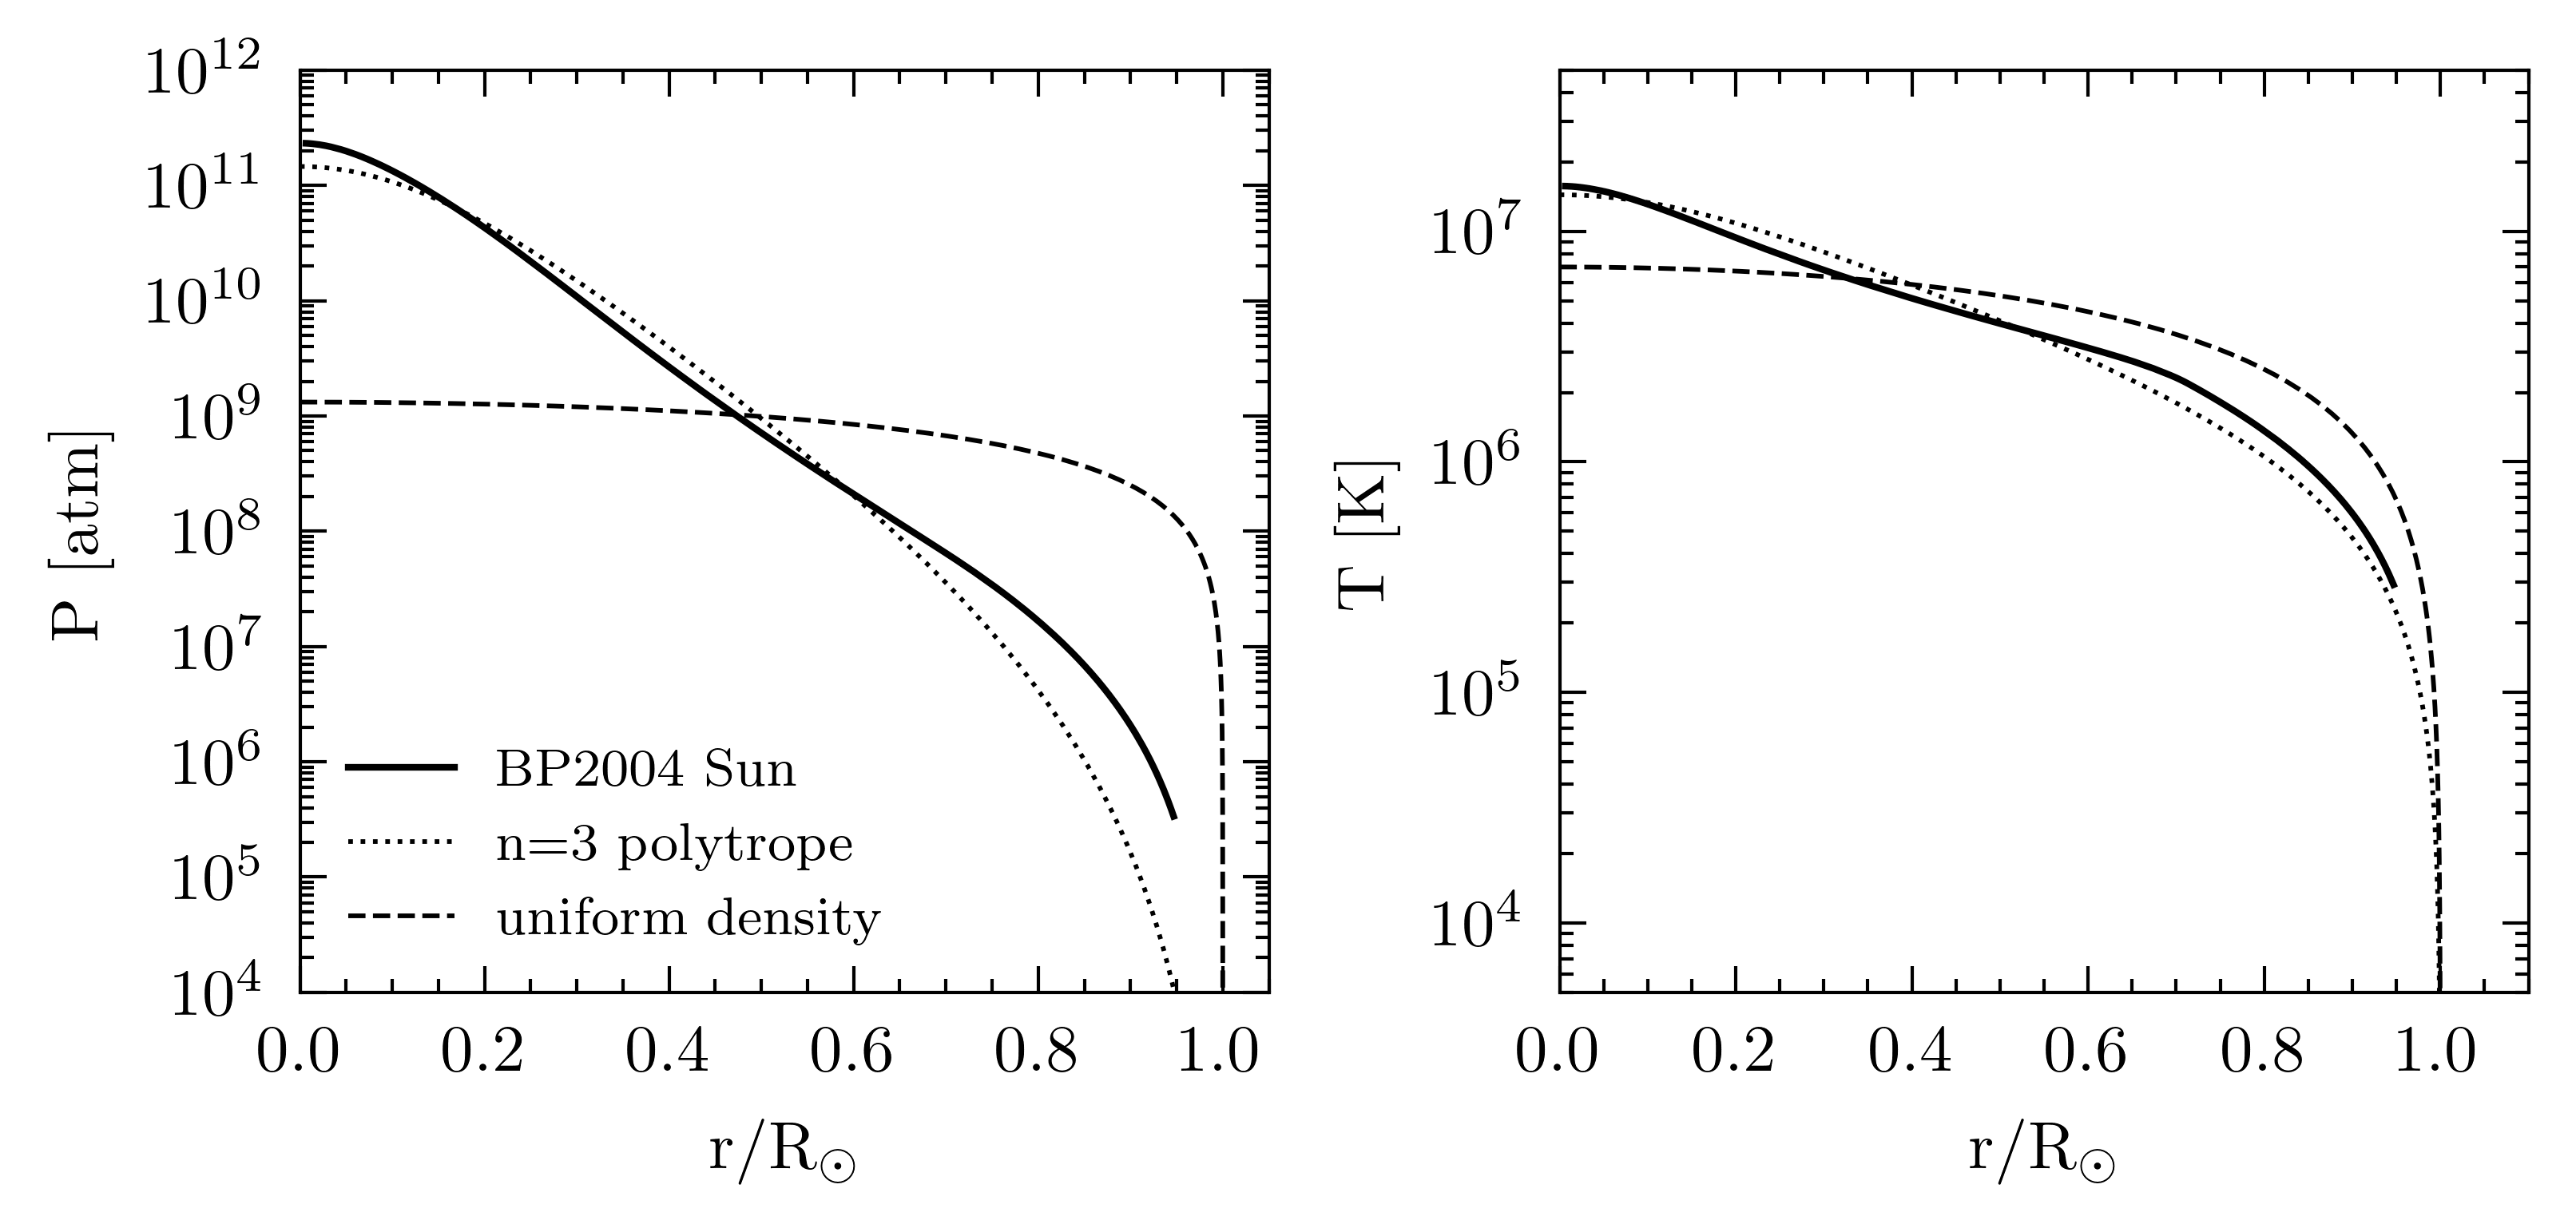

In [5]:
plotFile = 'SolarModel_BP2004.png'

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(wInches,hInches),dpi=dpi)
fig.subplots_adjust(wspace=0.3, hspace=0)

# Left Panel: P vs R

rMin = 0.0
rMax = 1.05
pMin = 1.0e4
pMax = 1.0e12

ax1.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax1.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax1.set_xlim(rMin,rMax)
ax1.set_xlabel(r'r/R$_{\odot}$',fontsize=axisFontSize)
ax1.xaxis.set_major_locator(MultipleLocator(0.2))
ax1.xaxis.set_minor_locator(MultipleLocator(0.05))
ax1.set_ylim(pMin,pMax)
ax1.set_ylabel(r'P [atm]',fontsize=axisFontSize)
ax1.set_yscale('log')
ax1.yaxis.set_major_locator(LogLocator(base=10.0,subs=(1.0,),numticks=100))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0,subs=np.arange(2,10)*0.1,numticks=100))
ax1.set_yticks([1.0e4,1.0e5,1.0e6,1.0e7,1.0e8,1.0e9,1.0e10,1.0e11,1.0e12])

ax1.plot(bpR,bpP,'-',color='black',lw=1.0,zorder=10,label='BP2004 Sun')
ax1.plot(modR,polyP,':',color='black',lw=0.7,zorder=10,label='n=3 polytrope')
ax1.plot(modR,uniP,'--',color='black',lw=0.7,zorder=10,label='uniform density')

leg = ax1.legend(loc='lower left',frameon=False,prop={'size':8})

# Right Panel: T vs R

rMin = 0
rMax = 1.1
tMin = 5.0e3
tMax = 5.0e7

ax2.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax2.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
ax2.set_xlim(rMin,rMax)
ax2.set_xlabel(r'r/R$_\odot$',fontsize=axisFontSize)
ax2.xaxis.set_major_locator(MultipleLocator(0.2))
ax2.xaxis.set_minor_locator(MultipleLocator(0.05))
ax2.set_ylim(tMin,tMax)
ax2.set_ylabel(r'T [K]',fontsize=axisFontSize)
ax2.set_yscale('log')
ax2.yaxis.set_major_locator(LogLocator(base=10.0,subs=(1.0,),numticks=100))
ax2.yaxis.set_minor_locator(LogLocator(base=10.0,subs=np.arange(2,10)*0.1,numticks=100))
ax2.set_yticks([1.0e4,1.0e5,1.0e6,1.0e7])

ax2.plot(bpR,bpT,'-',color='black',lw=1.0,zorder=10)
ax2.plot(modR,polyT,':',color='black',lw=0.7,zorder=10)
ax2.plot(modR,uniT,'--',color='black',lw=0.7,zorder=10)
    
# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()

## Gravitational Binding Energy

Compute the gravitational binding energy for the Sun for the three solar models.

In general, you can write the total gravitational binding energy of a sphere as:
\begin{equation}
   U_{grav} = -\alpha\frac{GM^2}{R}
\end{equation}
where $\alpha$ is a dimensionless factor.

For the uniform-density sphere:
\begin{equation}
   U_{grav,ud} = -\frac{3}{5}\frac{GM^2}{R}
\end{equation}
so $\alpha=\frac{3}{5}$

For a polytrope of index $n$:
\begin{equation}
   U_{grav,n} = -\frac{3}{5-n}\frac{GM^2}{R}
\end{equation}
Since the Sun is approximately $n=3$, $\alpha=\frac{3}{2}$

And lastly, we integrate the BP2004 model numerically, and divide by $GM^2/R$ to compute $\alpha$ because
our standard reference model Sun is not surprisingly not really an $n=3$ polytrope.

In [6]:
Ugrav_0 = -G*Msun*Msun/Rsun

Ugrav_ud = (3.0/5.0)*Ugrav_0

n=3
Ugrav_n3 = (3.0/(5-n))*Ugrav_0

# simpson's rule integration since model is well-behaved

from scipy import integrate

dUgrav = -4*np.pi*G*Mint*bpRho*rad

Ugrav_bp04 = integrate.simpson(y=dUgrav, x=rad)

alpha = Ugrav_bp04/Ugrav_0

print(f'Uniform-density sphere: Ugrav={Ugrav_ud:.5e} erg, alpha=3/5')
print(f'         n=3 Polytrope: Ugrav={Ugrav_n3:.5e} erg, alpha=3/2')
print(f' BP2004 model integral: Ugrav={Ugrav_bp04:.5e} erg, alpha={alpha:.3f}')

Uniform-density sphere: Ugrav=-2.27495e+49 erg, alpha=3/5
         n=3 Polytrope: Ugrav=-5.68738e+49 erg, alpha=3/2
 BP2004 model integral: Ugrav=-6.13140e+49 erg, alpha=1.617
